# DANDI → Experanto: Multimodal Conversion Guide

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DebDDash/experanto/blob/main/examples/dandi_experanto_example.ipynb)

Experanto provides a unified interface for loading and aligning neural data across modalities. The key idea is that each modality has a different temporal structure, and Experanto provides a dedicated interpolator for each case:

- **`SequenceInterpolator`** for regularly sampled continuous signals such as calcium imaging, LFP, or running speed, where every channel is recorded at a fixed rate
- **`PhaseShiftedSequenceInterpolator`** for regularly sampled signals where there is a constant time delay between channels, common in certain electrophysiology setups
- **`SpikeInterpolator`** for spike trains, which are point-based events (timestamps only, no amplitude), where the interpolator counts spikes within a window around each query time
- **`TimeIntervalInterpolator`** for interval-based events such as blinks, saccades, or behavioral states, where each event has a start and end time
- **`ScreenInterpolator`** for image or video stimuli, returning the frame that was on screen at any queried timepoint

For full details on each interpolator see the [Experanto documentation](https://experanto.readthedocs.io/en/latest/).

Below we provide a few examples of how to match DANDI datasets to the appropriate Experanto format, covering three structurally different NWB files across multiple modalities.

| Dataset | Modalities | Interpolator |
|---|---|---|
| DANDI:000128 — MC_Maze | Spike trains | `SpikeInterpolator` |
| DANDI:000039 — Allen Visual Coding | Calcium imaging (dF/F) | `SequenceInterpolator` |
| DANDI:000623 — Chandravadia et al. | Spikes, LFP, eye tracking, pupil | Multiple |



In [4]:
!pip install -q git+https://github.com/sensorium-competition/experanto.git@main
!pip install -q dandi pynwb
!pip install -q "numba>=0.61.0" --upgrade

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.9/370.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.0/70.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

> **Note:** After running the install cell, restart the runtime before proceeding.
Colab ships with numba 0.60.0 which doesn't support numpy 2.x. SpikeInterpolator uses numba internally, so this conflict occurs.

In [1]:
import os
import numpy as np
import yaml
import matplotlib.pyplot as plt
from pathlib import Path
from dandi.dandiapi import DandiAPIClient
from pynwb import NWBHDF5IO
from experanto.interpolators import SpikeInterpolator, SequenceInterpolator

In [2]:
def download_smallest(dandiset_id, dest):
    """
    Downloads the smallest file in a dandiset for testing purposes.
    In practice, you would select a specific asset by path or asset ID
    rather than sorting by size.
    """
    os.makedirs(dest, exist_ok=True)
    client = DandiAPIClient()
    assets = sorted(
        client.get_dandiset(dandiset_id).get_assets(),
        key=lambda x: x.size
    )
    path = f"{dest}/test.nwb"
    if not os.path.exists(path):
        print(f"Downloading {assets[0].path} ({round(assets[0].size/1e6, 1)} MB)")
        assets[0].download(path)
    else:
        print(f"Using cached: {path}")
    return path

In [ ]:
def inspect_nwb(nwb):
    """Print a summary of what modalities are present in an NWB file."""
    print("Acquisition:")
    for name, obj in nwb.acquisition.items():
        print(f"  {name}: {type(obj).__name__}")
    print("Processing modules:")
    for mod_name, module in nwb.processing.items():
        for dname, dobj in module.data_interfaces.items():
            print(f"  {mod_name}/{dname}: {type(dobj).__name__}")
    print(f"Units:  {len(nwb.units) if nwb.units else 'None'}")
    print(f"Trials: {len(nwb.trials) if nwb.trials else 'None'}")

In [ ]:
def detect_modalities(nwb):
    """
    Detect which Experanto modalities are present in an NWB file
    and suggest the appropriate interpolator for each.

    Only modalities that actually contain data are returned
    this ensures only the corresponding folders get created.

    Returns a dict mapping modality name → suggested interpolator.
    Always verify against the dataset documentation before converting.
    """
    modalities = {}

    if nwb.units is not None and "spike_times" in list(nwb.units.colnames):
        modalities["spikes"] = "SpikeInterpolator"

    for name, obj in nwb.acquisition.items():
        t = type(obj).__name__
        if "ElectricalSeries" in t:
            modalities[name.lower()] = "SequenceInterpolator"
        elif "NIRSSeries" in t:
            modalities[name.lower()] = "SequenceInterpolator"
        elif "ImageSeries" in t or "TwoPhotonSeries" in t:
            modalities[name.lower()] = "ScreenInterpolator"

    for _mod_name, module in nwb.processing.items():
        for dname, dobj in module.data_interfaces.items():
            t = type(dobj).__name__
            if "LFP" in t:
                for sname in dobj.electrical_series:
                    modalities[sname.lower()] = "SequenceInterpolator"
            elif "Fluorescence" in t:
                for sname in dobj.roi_response_series:
                    modalities[sname.lower()] = "SequenceInterpolator"
            elif "BehavioralTimeSeries" in t:
                for sname in dobj.time_series:
                    modalities[sname.lower()] = "SequenceInterpolator"
            elif "EyeTracking" in t:
                for sname in dobj.spatial_series:
                    modalities[sname.lower()] = "SequenceInterpolator"
            elif "PupilTracking" in t:
                for sname in dobj.time_series:
                    modalities[sname.lower()] = "SequenceInterpolator"
            elif "FiberPhotometry" in t:
                modalities[dname.lower()] = "SequenceInterpolator"
            elif "TimeSeries" in t:
                modalities[dname.lower()] = "SequenceInterpolator (verify manually)"

    for name, interp in modalities.items():
        print(f"  {name:5s} : {interp}")
    return modalities


# Spike Trains: DANDI:000128 MC_Maze

**Dataset:** [DANDI:000128](https://dandiarchive.org/dandiset/000128)

This dataset contains sorted unit spiking times and behavioral data from a macaque performing a delayed reaching task. The task was a center-out reaching task with obstructing barriers forming a maze, resulting in a variety of straight and curved reaches. Neural activity was recorded from electrode arrays implanted in motor cortex (M1) and dorsal premotor cortex (PMd). Cursor position, hand position, and eye position were also recorded, and hand velocity was calculated offline from hand position. Provided as part of the [Neural Latents Benchmark](https://neurallatents.github.io).

**What this tells us about interpolator choice:** The neural data here is spike trains — each neuron fires at irregular, unpredictable times. There is no meaningful "value" between spikes, so storing a dense matrix would waste space and misrepresent the data. This is exactly the case `SpikeInterpolator` is designed for: it stores only the raw timestamps and counts spikes within a window around each query time.

| Property | Value |
|---|---|
| Neurons | 137 |
| Trials | 574 |
| Modality | Spike trains |
| Interpolator | `SpikeInterpolator` |

In [5]:
path_128 = download_smallest("000128", "data/000128")
io128 = NWBHDF5IO(path_128, "r")
nwb128 = io128.read()
inspect_nwb(nwb128)

INFO:dandi:Asset 1bd112a4-5ec5-4033-ac30-d88e70e993d9 (3392688 bytes in 1 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/1bd112a4-5ec5-4033-ac30-d88e70e993d9/download/


Acquisition:
Processing modules:
Units:  137
Trials: 574


In [7]:
result_128 = detect_modalities(nwb128)

  spikes : SpikeInterpolator


In [6]:
def convert_spikes(nwb, output_dir):
    """
    Convert NWB spike times to SpikeInterpolator format.

    NWB stores one spike_times array per unit. SpikeInterpolator
    expects a single flat 1D array (spikes.npy) with all neurons
    concatenated and sorted within each block. spike_indices in
    meta.yml marks the boundary between each neuron's block.
    """
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    units_df = nwb.units.to_dataframe()
    trials_df = nwb.trials.to_dataframe()
    t_start = float(trials_df["start_time"].min())
    t_end = float(trials_df["stop_time"].max())
    n_neurons = len(units_df)

    all_spikes, spike_indices = [], [0]
    for _, unit in units_df.iterrows():
        spikes = np.sort(np.array(unit["spike_times"], dtype=np.float64))
        all_spikes.append(spikes)
        spike_indices.append(spike_indices[-1] + len(spikes))

    flat = np.concatenate(all_spikes)
    np.save(out / "spikes.npy", flat)
    yaml.safe_dump({
        "modality": "spikes",
        "start_time": t_start,
        "end_time": t_end,
        "n_signals": n_neurons,
        "spike_indices": [int(i) for i in spike_indices],
        "dtype": "float64",
        "is_mem_mapped": False,
    }, open(out / "meta.yml", "w"))

    print(f"Duration:         {t_end - t_start:.1f}s")
    print(f"Neurons:          {n_neurons}")
    print(f"Total spikes:     {len(flat):,}")
    print(f"Mean per neuron:  {len(flat)/n_neurons:.0f}")
    return flat, t_start, t_end

In [8]:
flat_128, t0_128, t1_128 = convert_spikes(nwb128, "experanto_000128/spikes")
io128.close()

Duration:         459.1s
Neurons:          137
Total spikes:     230,348
Mean per neuron:  1681


In [9]:
si128 = SpikeInterpolator(
    "experanto_000128/spikes",
    cache_data=True,
    interpolation_window=0.1,
    interpolation_align="center",
)

t = np.linspace(si128.start_time + 1, si128.start_time + 100, 500)
counts_128 = si128.interpolate(t)
print(f"Output shape: {counts_128.shape}")
print(f"Mean spikes per window: {counts_128.mean():.4f}")

Output shape: (500, 137)
Mean spikes per window: 0.3705


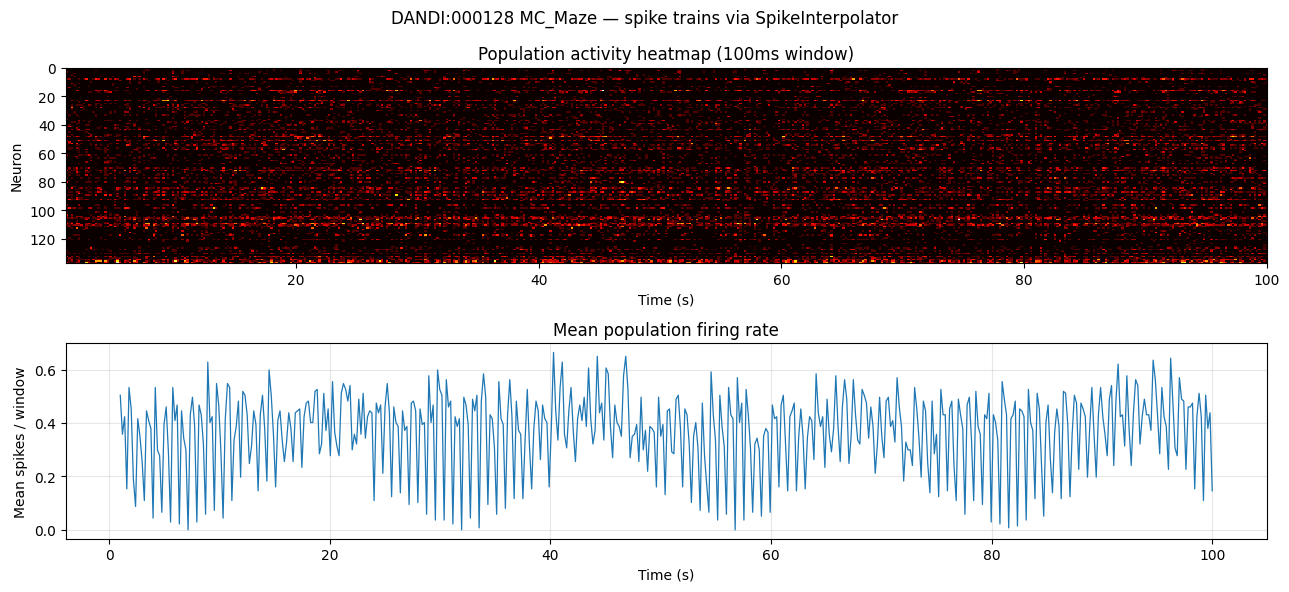

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
fig.suptitle("DANDI:000128 MC_Maze — spike trains via SpikeInterpolator")

axes[0].imshow(
    counts_128.T,
    aspect="auto",
    cmap="hot",
    interpolation="nearest",
    extent=[t[0], t[-1], counts_128.shape[1], 0]
)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Neuron")
axes[0].set_title("Population activity heatmap (100ms window)")

axes[1].plot(t, counts_128.mean(axis=1), lw=0.9)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Mean spikes / window")
axes[1].set_title("Mean population firing rate")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcium Imaging: DANDI:000039 Allen Visual Coding

**Dataset:** [DANDI:000039](https://dandiarchive.org/dandiset/000039)

A two-photon calcium imaging dataset from the Allen Institute measuring neural responses to full-field drifting gratings across 8 directions and 6 contrast levels. Mouse Cre lines expressing GCaMP6f were imaged to record responses of pyramidal neurons across cortical layers (Cux2: layer 2/3; Rorb: layer 4; Rbp4: layer 5; Ntsr1: layer 6) as well as inhibitory interneurons (Vip and Sst). A running wheel was also used to track locomotion during sessions. All sessions follow the same Allen Brain Observatory data collection pipeline.

**What this tells us about interpolator choice:** Calcium imaging records fluorescence (dF/F) at a fixed rate for every neuron at every timestep, this is a dense, regularly sampled signal. This is the case `SequenceInterpolator` is designed for.

| Property | Value |
|---|---|
| Species | Mouse |
| Modality | Calcium imaging (dF/F) |
| Sampling rate | ~30 Hz  |
| Interpolator | `SequenceInterpolator` |

In [11]:
path_039 = download_smallest("000039", "data/000039")
io039 = NWBHDF5IO(path_039, "r")
nwb039 = io039.read()
inspect_nwb(nwb039)

INFO:dandi:Asset 8f5bd91d-113e-4a41-afd2-5c7924a2bcc2 (27092080 bytes in 4 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/8f5bd91d-113e-4a41-afd2-5c7924a2bcc2/download/


Acquisition:
Processing modules:
  brain_observatory_pipeline/Fluorescence: Fluorescence
  brain_observatory_pipeline/ImageSegmentation: ImageSegmentation
  brain_observatory_pipeline/MotionCorrection: TimeSeries
  brain_observatory_pipeline/RunningBehavior: BehavioralTimeSeries
  brain_observatory_pipeline/l0_events: Fluorescence
  brain_observatory_pipeline/max_project: TwoPhotonSeries
  stimulus/timestamps: TimeSeries
Units:  3
Trials: None


In [12]:
result_039 = detect_modalities(nwb039)

  dfoverf : SequenceInterpolator
  demixed_traces : SequenceInterpolator
  neuropil_traces : SequenceInterpolator
  raw_traces : SequenceInterpolator
  motioncorrection : SequenceInterpolator (verify manually)
  running_speed : SequenceInterpolator
  dff_events : SequenceInterpolator
  true_false_events : SequenceInterpolator
  timestamps : SequenceInterpolator (verify manually)


In [13]:
def convert_sequence(data, timestamps, output_dir):
    """
    Save a regularly sampled signal to SequenceInterpolator format.

    time_delta computed as (end_time - start_time) / (n_samples - 1)
    when a fixed rate is not stored in the NWB file.

    Data is saved as a float32 matrix of shape (n_timestamps, n_signals).
    """
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    if data.ndim == 1:
        data = data.reshape(-1, 1)
    data = data.astype(np.float32)

    time_delta = float((timestamps[-1] - timestamps[0]) / (len(timestamps) - 1))

    np.save(out / "data.npy", data)
    yaml.safe_dump({
        "modality": "sequence",
        "sampling_rate": float(1.0 / time_delta),
        "time_delta": time_delta,
        "start_time": float(timestamps[0]),
        "end_time": float(timestamps[-1]),
        "n_signals": int(data.shape[1]),
        "n_timestamps": int(data.shape[0]),
        "dtype": "float32",
        "is_mem_mapped": False,
        "phase_shift_per_signal": False,
    }, open(out / "meta.yml", "w"))

    print(f"Shape:      {data.shape}")
    print(f"Rate:       {1/time_delta:.2f} Hz")
    print(f"Duration:   {timestamps[-1] - timestamps[0]:.1f}s")
    return data, timestamps

In [14]:
fluoro = nwb039.processing["brain_observatory_pipeline"]["Fluorescence"]
trace = fluoro.roi_response_series["DfOverF"]
ca_timestamps = trace.timestamps[:]
ca_data = trace.data[:]

deltas = np.diff(ca_timestamps)
print(f"Stored rate:  {trace.rate}  <- None means timestamps array is used")
print(f"Delta std:    {deltas.std():.2e}  <- ~zero, treating as regularly sampled")
print(f"Inferred rate: {1/deltas.mean():.2f} Hz")

ca_data, ca_ts = convert_sequence(ca_data, ca_timestamps, "experanto_000039/calcium")
io039.close()

Stored rate:  None  <- None means timestamps array is used
Delta std:    5.00e-06  <- ~zero, treating as regularly sampled
Inferred rate: 30.14 Hz
Shape:      (107115, 3)
Rate:       30.14 Hz
Duration:   3553.5s


In [15]:
seq039 = SequenceInterpolator("experanto_000039/calcium")

t_ca = np.linspace(seq039.start_time + 1, seq039.start_time + 100, 500)
ca_result = seq039.interpolate(t_ca)
print(f"Output shape: {ca_result.shape}")
print(f"Mean dF/F:    {ca_result.mean():.4f}")

Output shape: (500, 3)
Mean dF/F:    0.0625


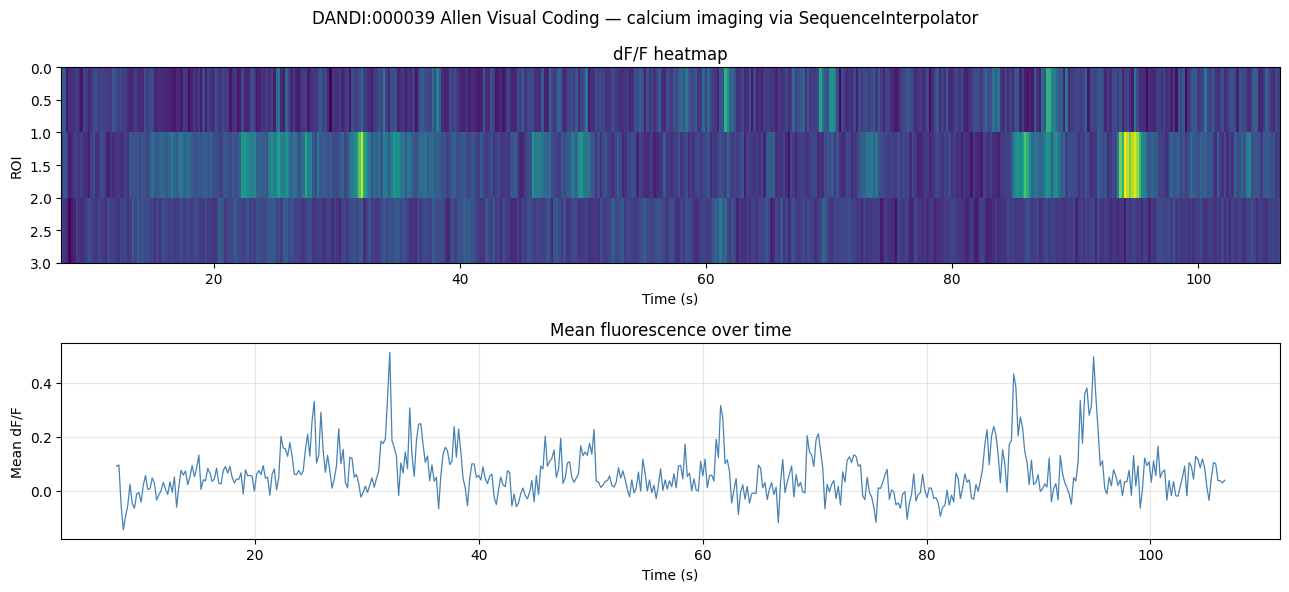

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
fig.suptitle("DANDI:000039 Allen Visual Coding — calcium imaging via SequenceInterpolator")

axes[0].imshow(
    ca_result.T,
    aspect="auto",
    cmap="viridis",
    interpolation="nearest",
    extent=[t_ca[0], t_ca[-1], ca_result.shape[1], 0]
)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("ROI")
axes[0].set_title("dF/F heatmap")

axes[1].plot(t_ca, ca_result.mean(axis=1), lw=0.9, color="steelblue")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Mean dF/F")
axes[1].set_title("Mean fluorescence over time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Multiple Modalities: DANDI:000623 Chandravadia et al.

**Dataset:** [DANDI:000623](https://dandiarchive.org/dandiset/000623)

A multimodal dataset of intracranial recordings, fMRI, and eye tracking from 20 human patients during movie watching. Participants watched an 8-minute excerpt from a film while neural activity was recorded from depth electrodes targeting the amygdala, hippocampus, and medial frontal cortex where electrodes arre implanted for epilepsy monitoring. Recordings include single neuron spike times, local field potential (LFP macro and micro), intracranial EEG, and eye tracking. A recognition memory test for movie content was administered after viewing. This dataset is formatted in both NWB and BIDS standards.

**What this tells us about interpolator choice:**  Five different modalities are present simultaneously, each requiring a different interpolator:

| Modality | Structure | Interpolator |
|---|---|---|
| Spike times | Irregular discrete timestamps | `SpikeInterpolator` |
| LFP macro | Regularly sampled continuous signal | `SequenceInterpolator` |
| LFP micro | Regularly sampled continuous signal | `SequenceInterpolator` |
| Eye tracking | Regularly sampled spatial coordinates | `SequenceInterpolator` |
| Pupil size | Regularly sampled continuous signal | `SequenceInterpolator` |

Rather than hardcoding which folders to create, `detect_modalities()` is called first to inspect the NWB file and confirm which modalities are actually present. Only existing modalities get a folder.

In [17]:
path_623 = download_smallest("000623", "data/000623")
io623 = NWBHDF5IO(path_623, "r")
nwb623 = io623.read()
inspect_nwb(nwb623)


INFO:dandi:Asset 7887e844-7100-4384-975e-5ee38dbf153d (492201332 bytes in 59 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/7887e844-7100-4384-975e-5ee38dbf153d/download/


Acquisition:
  events_ttl: TimeSeries
  experiment_ids: TimeSeries
Processing modules:
  behavior/Blink: BehavioralTimeSeries
  behavior/EyeTracking: EyeTracking
  behavior/Fixation: BehavioralTimeSeries
  behavior/PupilTracking: PupilTracking
  behavior/Saccade: BehavioralTimeSeries
  ecephys/LFP_macro: LFP
  ecephys/LFP_micro: LFP
Units:  44
Trials: 41


In [18]:
result_623 = detect_modalities(nwb623)

  spikes : SpikeInterpolator
  timeseries : SequenceInterpolator
  spatialseries : SequenceInterpolator
  electricalseries : SequenceInterpolator


In [19]:
base = "experanto_000623"
converted = {}

print("Converting spikes")
flat_623, t0_623, t1_623 = convert_spikes(nwb623, f"{base}/spikes")
converted["spikes"] = f"{base}/spikes"


Converting spikes
Duration:         721.3s
Neurons:          44
Total spikes:     76,279
Mean per neuron:  1734


In [20]:
print("\nConverting LFP macro")
lfp_macro = nwb623.processing["ecephys"]["LFP_macro"]
series = list(lfp_macro.electrical_series.values())[0]
data = series.data[:]
timestamps = np.arange(data.shape[0]) / series.rate
convert_sequence(data, timestamps, f"{base}/lfp_macro")
converted["lfp_macro"] = f"{base}/lfp_macro"


Converting LFP macro
Shape:      (732519, 40)
Rate:       1000.00 Hz
Duration:   732.5s


In [21]:
print("\nConverting LFP micro")
lfp_micro = nwb623.processing["ecephys"]["LFP_micro"]
series = list(lfp_micro.electrical_series.values())[0]
data = series.data[:]
timestamps = np.arange(data.shape[0]) / series.rate
convert_sequence(data, timestamps, f"{base}/lfp_micro")
converted["lfp_micro"] = f"{base}/lfp_micro"


Converting LFP micro
Shape:      (732343, 56)
Rate:       1000.00 Hz
Duration:   732.3s


In [22]:
print("\nConverting eye tracking")
eye = nwb623.processing["behavior"]["EyeTracking"]
series = list(eye.spatial_series.values())[0]
data = series.data[:]
timestamps = np.arange(data.shape[0]) / series.rate
convert_sequence(data, timestamps, f"{base}/eye_tracking")
converted["eye_tracking"] = f"{base}/eye_tracking"


Converting eye tracking
Shape:      (361151, 2)
Rate:       500.00 Hz
Duration:   722.3s


In [23]:
print("\nConverting pupil size")
pupil = nwb623.processing["behavior"]["PupilTracking"]
series = list(pupil.time_series.values())[0]
data = series.data[:]
timestamps = np.arange(data.shape[0]) / series.rate
convert_sequence(data, timestamps, f"{base}/pupil")
converted["pupil"] = f"{base}/pupil"




Converting pupil size
Shape:      (361151, 1)
Rate:       500.00 Hz
Duration:   722.3s


In [24]:
print(f"\nFolders written: {list(converted.keys())}")


Folders written: ['spikes', 'lfp_macro', 'lfp_micro', 'eye_tracking', 'pupil']


In [25]:
si623 = SpikeInterpolator(f"{base}/spikes", cache_data=True, interpolation_window=0.1, interpolation_align="center")
seq_lfp_macro = SequenceInterpolator(f"{base}/lfp_macro")
seq_lfp_micro = SequenceInterpolator(f"{base}/lfp_micro")
seq_eye = SequenceInterpolator(f"{base}/eye_tracking")
seq_pupil = SequenceInterpolator(f"{base}/pupil")

t_start = max(si623.start_time, seq_lfp_macro.start_time, seq_eye.start_time) + 1
t_end = t_start + 60
t_623 = np.linspace(t_start, t_end, 500)

spikes_623 = si623.interpolate(t_623)
lfp_macro_623 = seq_lfp_macro.interpolate(t_623)
lfp_micro_623 = seq_lfp_micro.interpolate(t_623)
eye_623 = seq_eye.interpolate(t_623)
pupil_623 = seq_pupil.interpolate(t_623)

for name, result in [("spikes", spikes_623), ("lfp_macro", lfp_macro_623),
                      ("lfp_micro", lfp_micro_623), ("eye", eye_623), ("pupil", pupil_623)]:
    print(f"  {name}: shape={result.shape}  OK")

  spikes: shape=(500, 44)  OK
  lfp_macro: shape=(500, 40)  OK
  lfp_micro: shape=(500, 56)  OK
  eye: shape=(500, 2)  OK
  pupil: shape=(500, 1)  OK


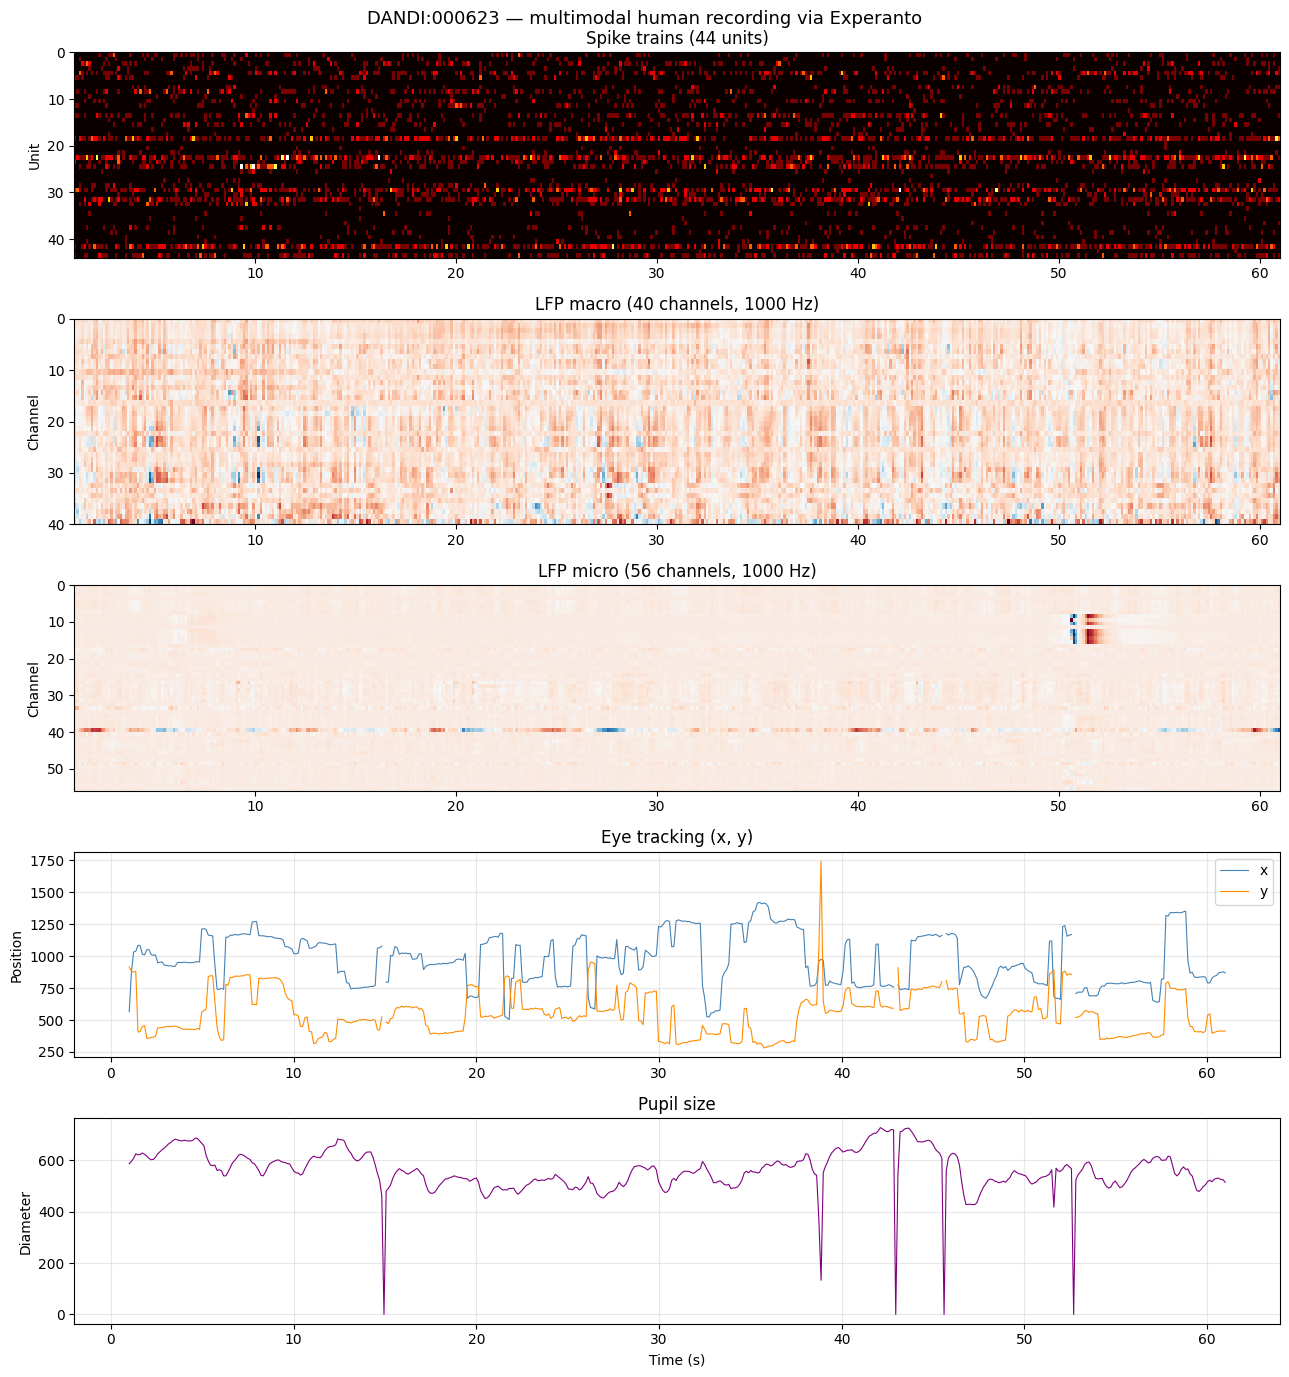

In [26]:
fig, axes = plt.subplots(5, 1, figsize=(13, 14))
fig.suptitle("DANDI:000623 — multimodal human recording via Experanto", fontsize=13)

# Spikes
axes[0].imshow(spikes_623.T, aspect="auto", cmap="hot", interpolation="nearest",
               extent=[t_623[0], t_623[-1], spikes_623.shape[1], 0])
axes[0].set_title("Spike trains (44 units)")
axes[0].set_ylabel("Unit")

# LFP macro
axes[1].imshow(lfp_macro_623.T, aspect="auto", cmap="RdBu_r", interpolation="nearest",
               extent=[t_623[0], t_623[-1], lfp_macro_623.shape[1], 0])
axes[1].set_title("LFP macro (40 channels, 1000 Hz)")
axes[1].set_ylabel("Channel")

# LFP micro
axes[2].imshow(lfp_micro_623.T, aspect="auto", cmap="RdBu_r", interpolation="nearest",
               extent=[t_623[0], t_623[-1], lfp_micro_623.shape[1], 0])
axes[2].set_title("LFP micro (56 channels, 1000 Hz)")
axes[2].set_ylabel("Channel")

# Eye tracking
axes[3].plot(t_623, eye_623[:, 0], lw=0.8, label="x", color="steelblue")
axes[3].plot(t_623, eye_623[:, 1], lw=0.8, label="y", color="darkorange")
axes[3].set_title("Eye tracking (x, y)")
axes[3].set_ylabel("Position")
axes[3].legend(loc="upper right")
axes[3].grid(True, alpha=0.3)

# Pupil
axes[4].plot(t_623, pupil_623[:, 0], lw=0.8, color="purple")
axes[4].set_title("Pupil size")
axes[4].set_xlabel("Time (s)")
axes[4].set_ylabel("Diameter")
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

io623.close()

## Effect of Interpolation Window on Spike Trains
The `interpolation_window` parameter controls how wide a time window is used to
count spikes around each query point. Wider windows produce smoother firing rate
estimates but blur fine temporal structure. Narrower windows preserve temporal
precision but are noisier. Adjust `interpolation_window` in `SpikeInterpolator`
to control this trade-off.

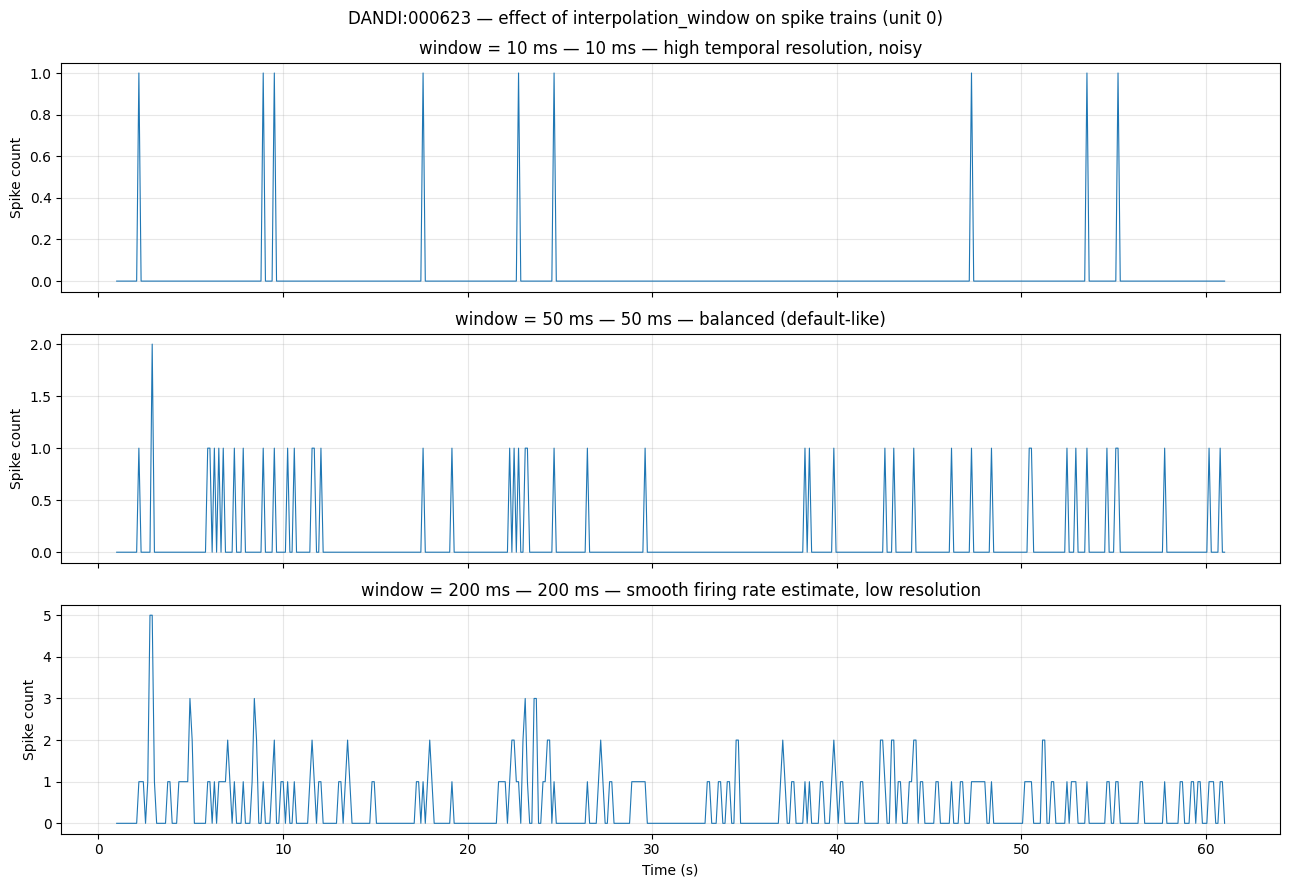

In [ ]:

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle("DANDI:000623 — effect of interpolation_window on spike trains (unit 0)", fontsize=12)

windows = [0.01, 0.05, 0.2]
labels = ["10 ms — high temporal resolution, noisy",
          "50 ms — balanced (default-like)",
          "200 ms — smooth firing rate estimate, low resolution"]

for ax, w, label in zip(axes, windows, labels, strict=False):
    si = SpikeInterpolator(
        "experanto_000623/spikes",
        cache_data=True,
        interpolation_window=w,
        interpolation_align="center",
    )
    counts = si.interpolate(t_623)
    ax.plot(t_623, counts[:, 0], lw=0.8)
    ax.set_title(f"window = {int(w*1000)} ms — {label}")
    ax.set_ylabel("Spike count")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## Effect of Query Resolution on LFP Macro
`SequenceInterpolator` returns values at whatever timepoints you request.
Here we query the same 10-second window at three different resolutions.
Coarser queries effectively downsample the signal, which is useful for aligning
with slower modalities like calcium imaging, but high-frequency content is lost.
Choose your query resolution to match the slowest modality in your pipeline.

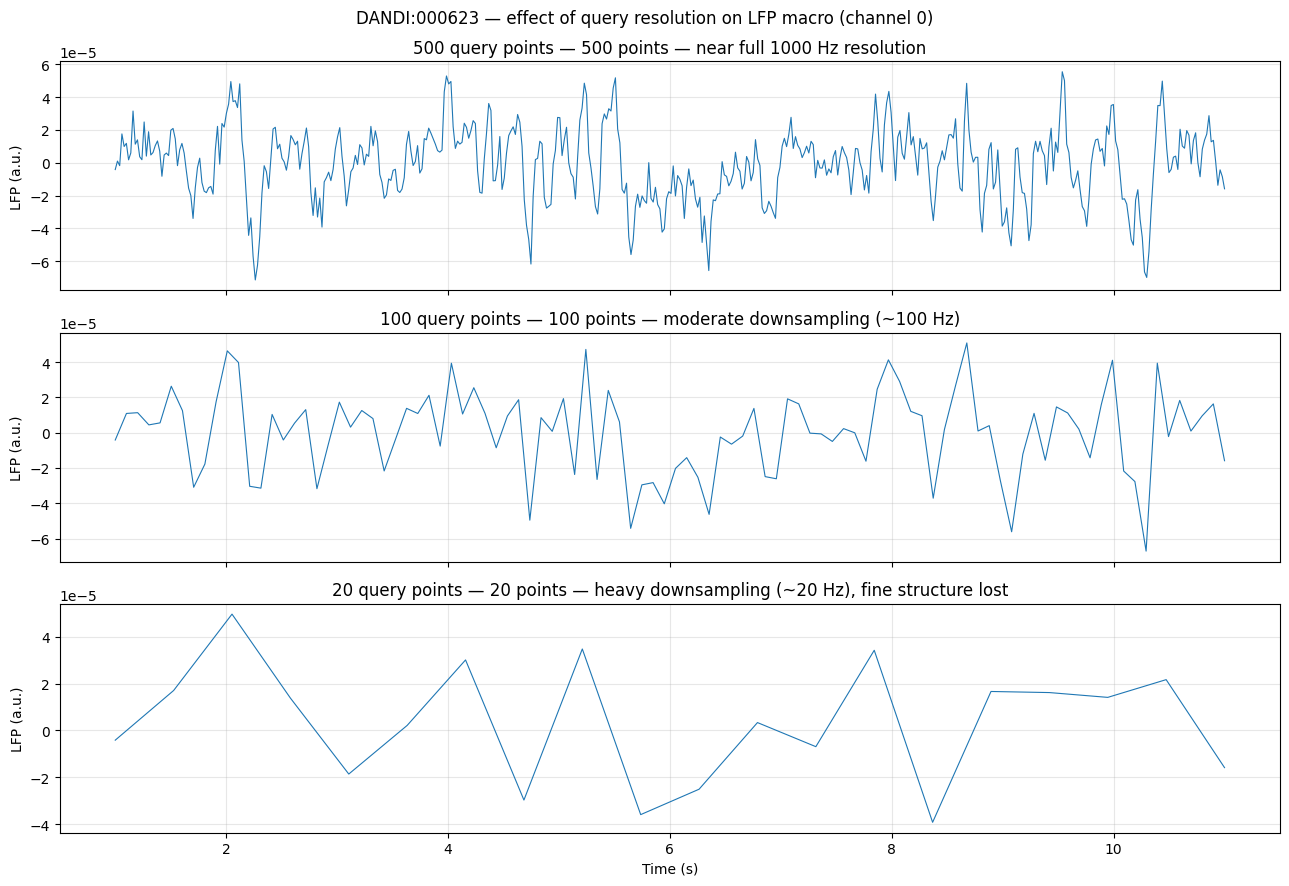

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle("DANDI:000623 — effect of query resolution on LFP macro (channel 0)", fontsize=12)

n_points = [500, 100, 20]
labels = ["500 points — near full 1000 Hz resolution",
          "100 points — moderate downsampling (~100 Hz)",
          "20 points — heavy downsampling (~20 Hz), fine structure lost"]

seq_lfp = SequenceInterpolator("experanto_000623/lfp_macro")
t_window = np.linspace(t_623[0], t_623[0] + 10, max(n_points))  # 10s window

for ax, n, label in zip(axes, n_points, labels, strict=False):
    t_query = np.linspace(t_623[0], t_623[0] + 10, n)
    result = seq_lfp.interpolate(t_query)
    ax.plot(t_query, result[:, 0], lw=0.8)
    ax.set_title(f"{n} query points — {label}")
    ax.set_ylabel("LFP (a.u.)")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()